# Case study: concept vs. context steering

Attribution graphs expose two classes of features available for intervention. **Concept** features fire strictly on the tokens of the concept itself (*baseball bat*) - the target $f^{(txt,11)}_{baseball-bat}$ together with several other features active on the same tokens. **Context** features fire on semantically related but syntactically distinct tokens (*ball*, *batter*, *hand*, *glove*) and are read off the concept's graph.

Suppressing each class is qualitatively different (prompt *a baseball bat on a table*):
- **concept** -> the bat is replaced by a nearby object (a ball);
- **context** -> the morphology survives but associations are dismantled (a stick);
- **concept + context** -> nothing reminiscent of a bat or baseball remains.

SAE methods can only reach the concept features because the context channel is surfaced only by the graph.

In [1]:
import os

os.environ.setdefault("TRANSCODERS_DIR", "/path/to/transcoders")

from transcoder_circuits.replacement_model import LRMConfig
from transcoder_circuits.circuit_analysis import LRMPipeline

cfg = LRMConfig(target_layers=tuple(range(16)))
pipeline = LRMPipeline(cfg)
pipeline.initialize()
pipeline.load_transcoders()
pipe, transcoders = pipeline.pipe, pipeline.transcoders

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

concept: 3 seeds | 'a baseball bat on a table'
    seed 0 (1/3)


  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

    seed 1 (2/3)


  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

    seed 2 (3/3)


  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

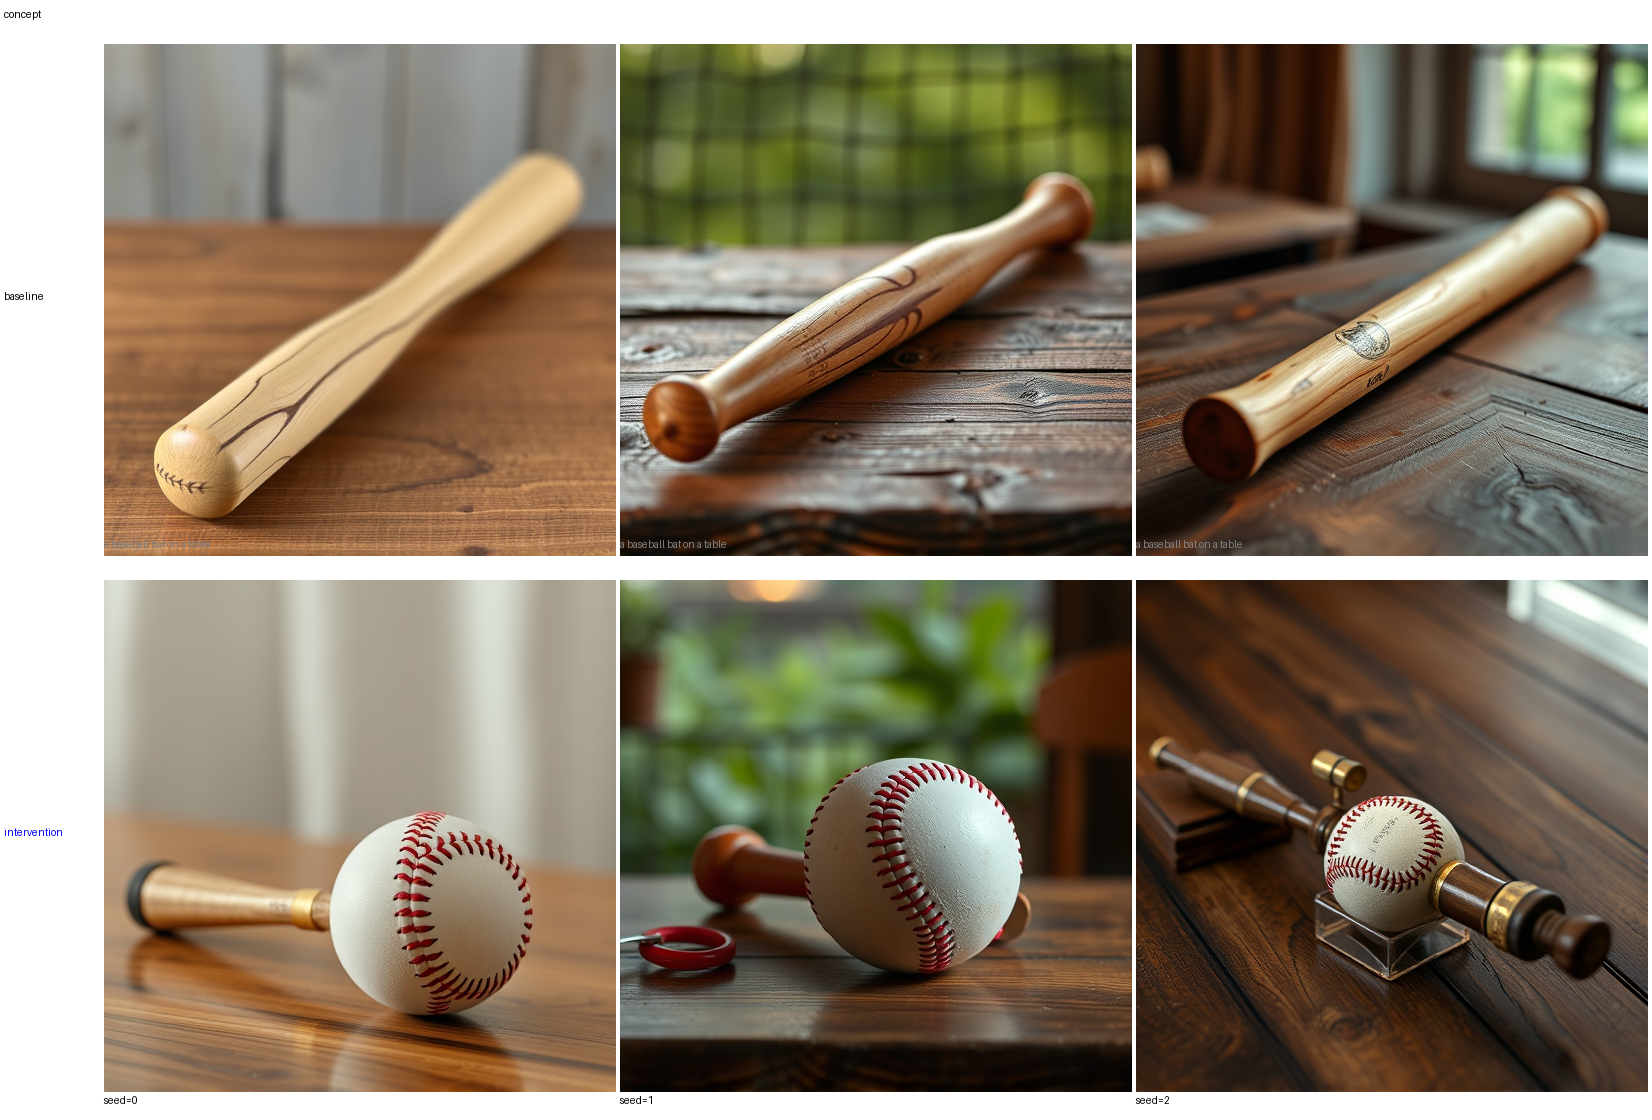

context: 3 seeds | 'a baseball bat on a table'
    seed 0 (1/3)


  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

    seed 1 (2/3)


  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

    seed 2 (3/3)


  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

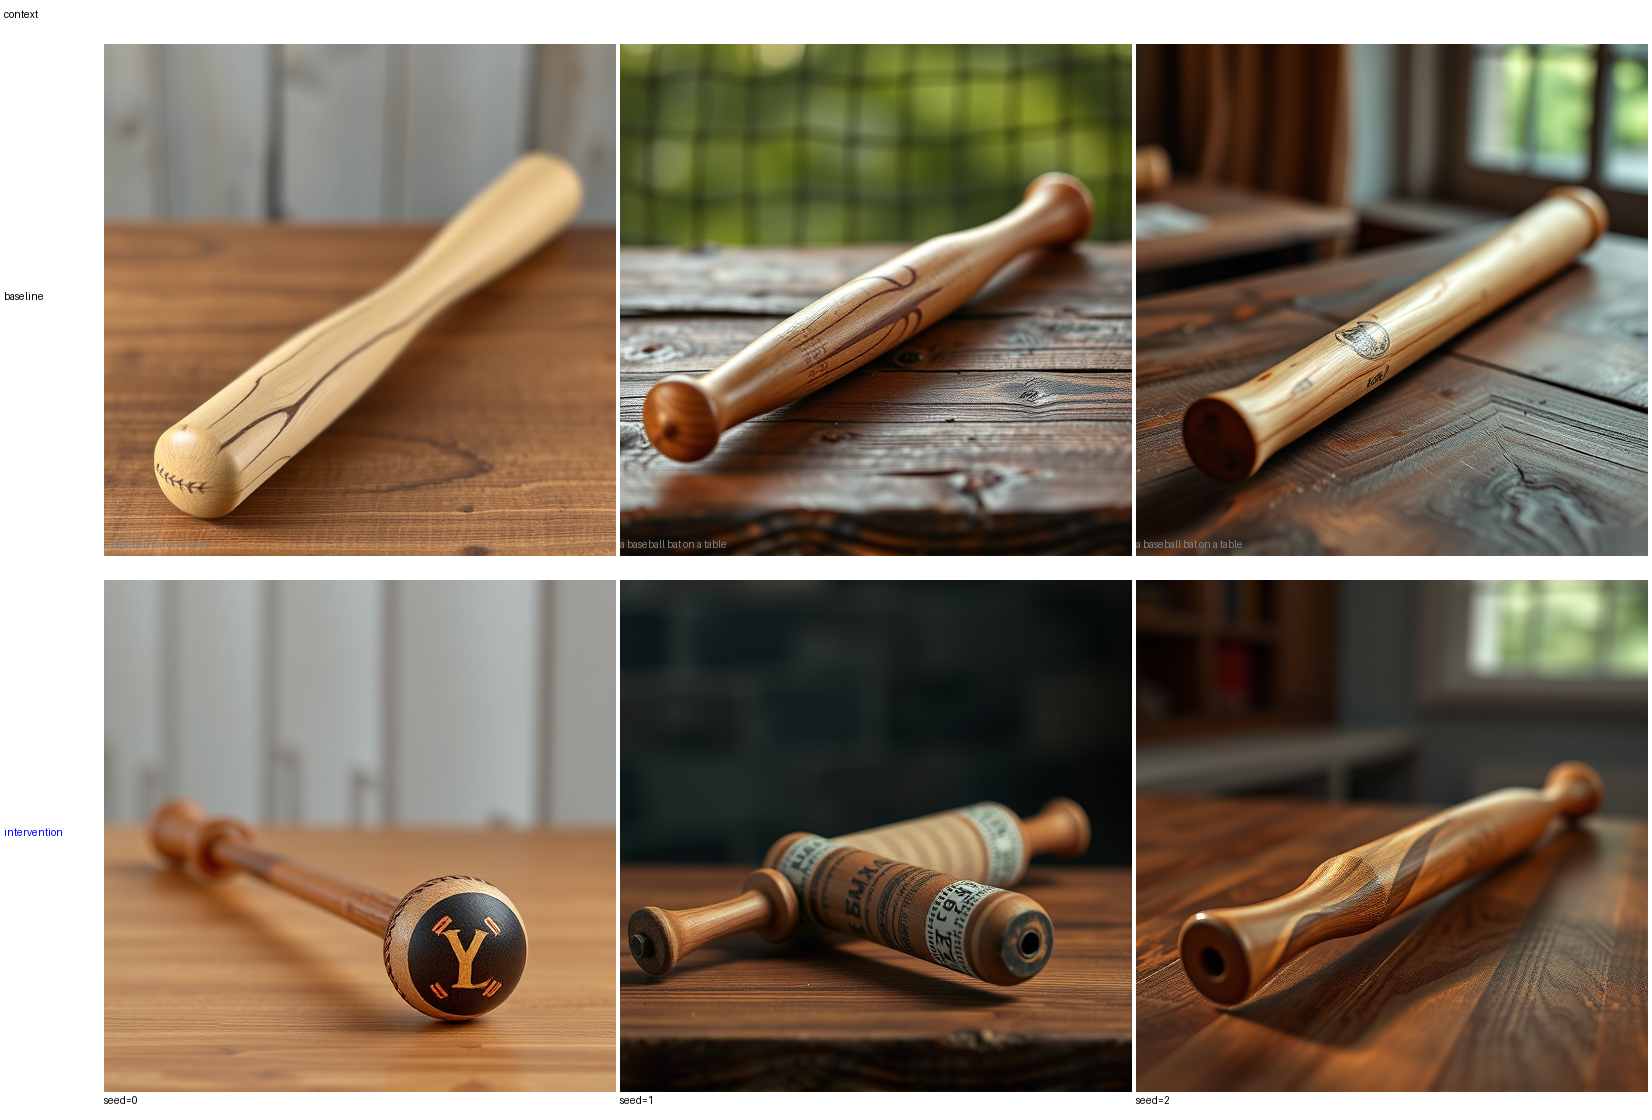

concept+context: 3 seeds | 'a baseball bat on a table'
    seed 0 (1/3)


  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

    seed 1 (2/3)


  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

    seed 2 (3/3)


  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

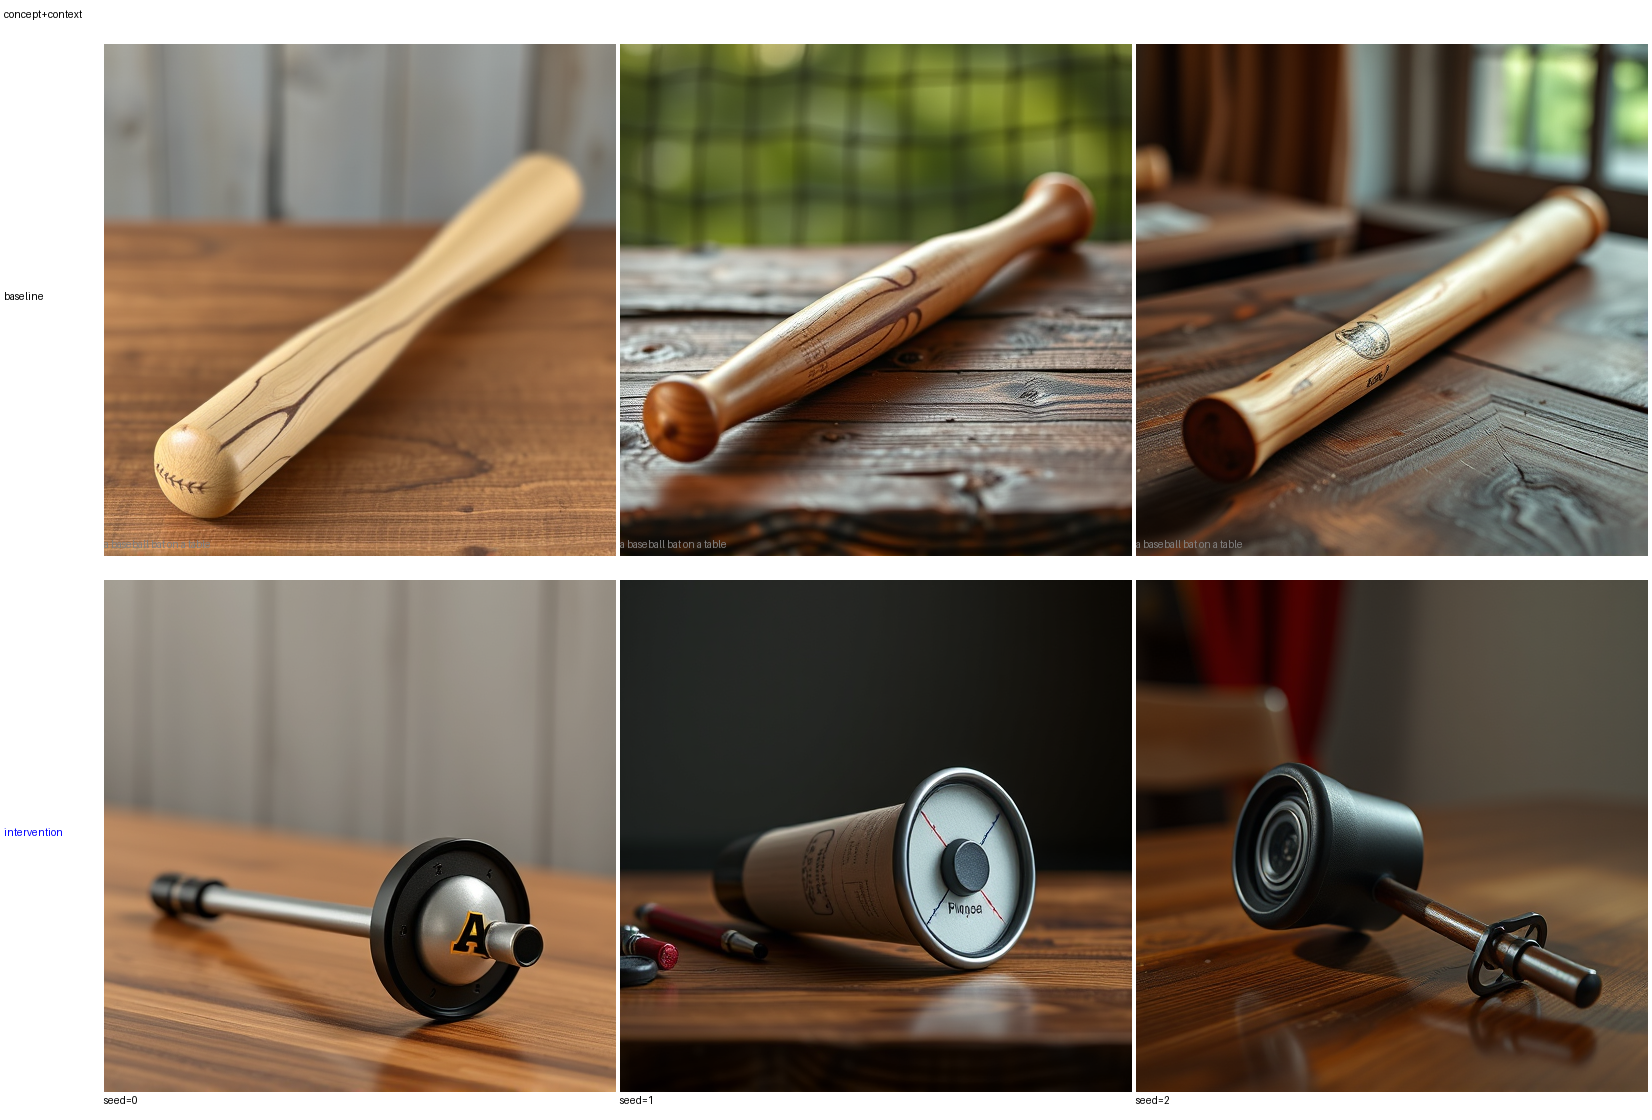

[{'seed': 0,
  'prompt': 'a baseball bat on a table',
  'config_name': 'concept',
  'baseline': <PIL.Image.Image image mode=RGB size=512x512>,
  'intervention': <PIL.Image.Image image mode=RGB size=512x512>},
 {'seed': 1,
  'prompt': 'a baseball bat on a table',
  'config_name': 'concept',
  'baseline': <PIL.Image.Image image mode=RGB size=512x512>,
  'intervention': <PIL.Image.Image image mode=RGB size=512x512>},
 {'seed': 2,
  'prompt': 'a baseball bat on a table',
  'config_name': 'concept',
  'baseline': <PIL.Image.Image image mode=RGB size=512x512>,
  'intervention': <PIL.Image.Image image mode=RGB size=512x512>},
 {'seed': 0,
  'prompt': 'a baseball bat on a table',
  'config_name': 'context',
  'baseline': <PIL.Image.Image image mode=RGB size=512x512>,
  'intervention': <PIL.Image.Image image mode=RGB size=512x512>},
 {'seed': 1,
  'prompt': 'a baseball bat on a table',
  'config_name': 'context',
  'baseline': <PIL.Image.Image image mode=RGB size=512x512>,
  'intervention': <PI

In [2]:
from transcoder_circuits.interventions import (
    InterventionRunner,
    InterventionConfig,
    FeatureIntervention,
)

# Concept: the target f^(txt,11)_baseball-bat plus graph features that fire on the concept tokens.
CONCEPT = [
    (11, "txt", 12936),
    (9, "txt", 15679),
    (8, "txt", 4275),
    (8, "txt", 36574),
    (7, "txt", 44183),
]
# Context: equally many baseball-associated txt sources read off the concept's graph.
CONTEXT = [
    (9, "txt", 29294),
    (8, "txt", 17492),
    (7, "txt", 23968),
    (6, "txt", 2697),
    (5, "txt", 38136),
]

PROMPT = "a baseball bat on a table"
SEEDS = [0, 1, 2]
runner = InterventionRunner(pipe, transcoders)


def suppress(features, alpha):
    return [
        FeatureIntervention(layer=l, stream=s, feat_idx=i, mode="amplify", scale=alpha)
        for (l, s, i) in features
    ]


configs = [
    InterventionConfig(
        f"concept", PROMPT, SEEDS, interventions=suppress(CONCEPT, -15.0)
    ),
    InterventionConfig(
        f"context", PROMPT, SEEDS, interventions=suppress(CONTEXT, -15.0)
    ),
    InterventionConfig(
        f"concept+context",
        PROMPT,
        SEEDS,
        interventions=suppress(CONCEPT + CONTEXT, -15.0),
    ),
]
runner.run_experiment(configs, output_dir=f"concept_context_out")